# 🛒⚡ Türkçe E-Ticaret NER: Qwen3-0.6B Fine-Tuning & 5 Modelli SOTA Benchmark

Bu notebook, **1.700 adetlik doğal Türkçe e-ticaret NER veri seti** (`gururaser/turkish-ecommerce-ner-dataset`) kullanılarak **`Qwen/Qwen3-0.6B`** modelinin **Unsloth + Response Masking** altyapısıyla L4 GPU üzerinde fine-tune edilmesini, 200 adetlik görünmemiş test kümesinde 5 farklı SOTA modelle **CANLI & DİNAMİK** olarak karşılaştırılmasını ve eğitilen modelin özenli bir Model Kartı (`README.md`) ile Hugging Face Hub'a yüklenmesini içermektedir.

### 📊 Değerlendirilen 5 Model Kadrosu
1. **Fine-Tuned Model**: `gururaser/qwen3-0.6b-turkish-ecommerce-ner` (Unsloth SFT + Prompt Masking)
2. **GLiNER2**: `fastino/gliner2-base-v1` (Zero-Shot SOTA Yapılandırılmış Veri Çıkarıcı)
3. **GLiNER**: `urchade/gliner_multi-v2.1` (Zero-Shot SOTA Çok Dilli NER)
4. **BERT-Turkish-NER**: `savasy/bert-base-turkish-ner-cased` (Geleneksel Türkçe BERT)
5. **Base Qwen3-0.6B**: `Qwen/Qwen3-0.6B` (Eğitilmemiş Taban LLM Zero-Shot)

## 0. Kütüphane Kurulumu (Google Colab / GPU Ortamı)

In [1]:
# les2 UYUMLU UNSLOTH VE TRL SÜRÜM KURULUMU
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth gliner gliner2 seqeval evaluate matplotlib pandas python-dotenv huggingface_hub tqdm
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
    !pip install transformers==4.56.2
    !pip install --no-deps trl==0.22.2
    !pip install gliner gliner2 seqeval evaluate matplotlib pandas python-dotenv tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 130.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 48.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 MB 10.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 36.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 18.1 MB/s eta 0:00:0000:01
   ━━━━━

## 1. Bağımlılıkların İçe Aktarılması ve Ortam Kontrolü

In [2]:
import sys
import torch
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from dotenv import load_dotenv
from tqdm.auto import tqdm

load_dotenv()

print(f"PyTorch Sürümü: {torch.__version__}")
print(f"CUDA Aktif mi: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Modeli: {torch.cuda.get_device_name(0)}")


PyTorch Sürümü: 2.11.0+cu128
CUDA Aktif mi: True
GPU Modeli: NVIDIA L4


## 2. Veri Setinin Yüklenmesi ve Bölümlenmesi

In [3]:
dataset_name = "gururaser/turkish-ecommerce-ner-dataset"
print(f"[BİLGİ] Hugging Face Hub'dan '{dataset_name}' verisi yükleniyor...")

raw_ds = load_dataset(dataset_name, split="train")
total_samples = len(raw_ds)
print(f"[BİLGİ] Toplam Veri Sayısı: {total_samples}")

# Deterministik Bölümleme (1.500 Eğitim / 200 Benchmark Test)
train_ds = raw_ds.select(range(0, min(1500, total_samples - 200)))
test_ds = raw_ds.select(range(total_samples - 200, total_samples))

print(f"✅ Eğitim Seti Boyutu: {len(train_ds)} kayıt")
print(f"✅ Benchmark Test Seti Boyutu: {len(test_ds)} kayıt")

# Örnek Kayıt Gösterimi
print("\n--- TEST SETİNDEN GERÇEK ÖRNEK KAYIT ---")
print(json.dumps(test_ds[0], ensure_ascii=False, indent=2))


[BİLGİ] Hugging Face Hub'dan 'gururaser/turkish-ecommerce-ner-dataset' verisi yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1700 [00:00<?, ? examples/s]

[BİLGİ] Toplam Veri Sayısı: 1700
✅ Eğitim Seti Boyutu: 1500 kayıt
✅ Benchmark Test Seti Boyutu: 200 kayıt

--- TEST SETİNDEN GERÇEK ÖRNEK KAYIT ---
{
  "id": "ecom_ner_01501",
  "product_name": "Dalan Natural %100 Organik Hindistan Cevizi Yağlı Doğal Sabun 250 ml",
  "category_domain": "Kişisel Bakım",
  "entities": [
    {
      "text": "Dalan Natural",
      "label": "BRAND",
      "start": 0,
      "end": 13
    },
    {
      "text": "Organik Hindistan Cevizi Yağlı",
      "label": "MATERIAL",
      "start": 19,
      "end": 49
    },
    {
      "text": "Doğal Sabun",
      "label": "CATEGORY",
      "start": 50,
      "end": 61
    },
    {
      "text": "250 ml",
      "label": "SIZE_VARIANT",
      "start": 62,
      "end": 68
    }
  ]
}


## 3. Unsloth ile Qwen3-0.6B Modeli ve LoRA Adaptörünün Yüklenmesi

In [ ]:
from unsloth import FastLanguageModel

max_seq_length = 512
dtype = None  # Autodetect (Bfloat16 for L4)
load_in_4bit = True

base_model_name = "Qwen/Qwen3-0.6B"
print(f"[BİLGİ] Taban Model Yükleniyor: {base_model_name}...")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=base_model_name,
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
)

# LoRA Adaptör Konfigürasyonu (r=16, alpha=16)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)
print("✅ Unsloth FastLanguageModel + LoRA Adaptörü başarıyla yüklendi!")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[BİLGİ] Taban Model Yükleniyor: Qwen/Qwen3-0.6B...
==((====))==  Unsloth 2026.7.5: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Unsloth 2026.7.5 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ Unsloth FastLanguageModel + LoRA Adaptörü başarıyla yüklendi!


## 4. Formatlama ve SFTTrainer + Prompt Masking ile Fine-Tuning Eğitimi

In [5]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

prompt_system = "Sen e-ticaret ürün isimlerinden marka, kategori, renk, beden, cinsiyet ve malzeme gibi NER bileşenlerini çıkaran uzman bir sistemdir."

def format_prompts(batch):
    texts = []
    for title, domain, entities in zip(batch["product_name"], batch["category_domain"], batch["entities"]):
        user_input = f"Kategori: {domain}\nÜrün Adı: {title}"
        response_json = json.dumps({"product_name": title, "entities": entities}, ensure_ascii=False)
        text = f"<|im_start|>system\n{prompt_system}<|im_end|>\n<|im_start|>user\n{user_input}<|im_end|>\n<|im_start|>assistant\n{response_json}<|im_end|>"
        texts.append(text)
    return {"text": texts}

formatted_train_ds = train_ds.map(format_prompts, batched=True)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=formatted_train_ds,
    args=SFTConfig(
        dataset_text_field="text",
        max_seq_length=max_seq_length,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        warmup_steps=10,
        max_steps=200,  # 200 adımlı yüksek başarı eğitimi
        learning_rate=3e-4,
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        report_to="none",
        output_dir="outputs",
    ),
)

# Yalnızca Asistan Cevaplarını Eğitme (Prompt Masking)
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|im_start|>user\n",
    response_part="<|im_start|>assistant\n",
)

print("🚀 Fine-Tuning Eğitimi Başlatılıyor (Response-Only Masking Aktif)... ")
trainer_stats = trainer.train()
print(f"✅ Eğitim Tamamlandı! Harcanan Süre: {trainer_stats.metrics['train_runtime']:.1f} saniye")


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1500 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

🚀 Fine-Tuning Eğitimi Başlatılıyor (Response-Only Masking Aktif)... 


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,500 | Num Epochs = 3 | Total steps = 200
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,0.607600
20,0.125700
30,0.079000
40,0.063900
50,0.054700
60,0.050600
70,0.051000
80,0.046600
90,0.038900
100,0.041500


✅ Eğitim Tamamlandı! Harcanan Süre: 176.0 saniye


## 5. Dinamik Metrik Hesaplama Motoru (Evaluator)

In [6]:
def calculate_ner_metrics(true_records, pred_records):
    """Canlı çıktılardan F1-Score, Precision, Recall ve Exact Match hesaplar."""
    total = len(true_records)
    exact_matches = 0
    tp, fp, fn = 0, 0, 0
    
    for true_item, pred_item in zip(true_records, pred_records):
        true_ents = set((e["text"].strip().lower(), e["label"].strip().upper()) for e in true_item.get("entities", []))
        pred_ents = set((e["text"].strip().lower(), e["label"].strip().upper()) for e in pred_item.get("entities", []))
        
        if true_ents == pred_ents:
            exact_matches += 1
            
        tp += len(true_ents.intersection(pred_ents))
        fp += len(pred_ents - true_ents)
        fn += len(true_ents - pred_ents)
        
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    em_rate = (exact_matches / total) * 100 if total > 0 else 0.0
    
    return {
        "F1-Score": round(f1, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "Exact Match": f"{em_rate:.1f}%",
    }

print("✅ Dinamik Metrik Hesaplama Motoru Hazır!")


✅ Dinamik Metrik Hesaplama Motoru Hazır!


## 6. 5-Model Benchmark Değerlendirmeleri

### 6.1. Model 1: Fine-Tuned Qwen3-0.6B (Unsloth SFT)

In [7]:
# MODEL 1: Fine-Tuned Qwen3-0.6B (Doğru Token Slicing ile Çıkarım)
benchmark_results = []
test_items = list(test_ds)
test_titles = [item["product_name"] for item in test_items]
gliner_labels = ["brand", "category", "model", "color", "size", "gender", "material", "specification"]

print(f"[1/5] Canlı Değerlendirme: Fine-Tuned Qwen3-0.6B ({len(test_items)} Kayıt)...", flush=True)
start_time = time.time()
pred_ft_records = []

FastLanguageModel.for_inference(model)
for item in tqdm(test_items, desc="Qwen3-0.6B Çıkarımı"):
    title = item["product_name"]
    domain = item["category_domain"]
    user_input = f"Kategori: {domain}\nÜrün Adı: {title}"
    prompt = f"<|im_start|>system\n{prompt_system}<|im_end|>\n<|im_start|>user\n{user_input}<|im_end|>\n<|im_start|>assistant\n"
    
    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
    input_len = inputs["input_ids"].shape[1]
    outputs = model.generate(**inputs, max_new_tokens=256, use_cache=True)
    
    # Sadece üretilen yeni token'ları decode et
    gen_tokens = outputs[0][input_len:]
    res_str = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
    
    try:
        pred_data = json.loads(res_str)
        pred_ft_records.append(pred_data)
    except Exception:
        pred_ft_records.append({"product_name": title, "entities": []})

latency_ft = int(((time.time() - start_time) / len(test_items)) * 1000)
m1_metrics = calculate_ner_metrics(test_items, pred_ft_records)
m1_metrics["Model"] = "Qwen3-0.6B (Fine-Tuned Unsloth)"
m1_metrics["Inference Süresi (ms)"] = latency_ft
benchmark_results.append(m1_metrics)
print(f"✅ Qwen3-0.6B Tamamlandı! F1: {m1_metrics['F1-Score']}", flush=True)


[1/5] Canlı Değerlendirme: Fine-Tuned Qwen3-0.6B (200 Kayıt)...


Qwen3-0.6B Çıkarımı:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Qwen3-0.6B Tamamlandı! F1: 0.855


### 6.2. Model 2: GLiNER2 (fastino/gliner2-base-v1)

In [15]:
# MODEL 2: GLiNER2 (fastino/gliner2-base-v1) - Düzeltilmiş & Tip Korumalı
print(f"[2/5] Canlı Değerlendirme: GLiNER2 (fastino/gliner2-base-v1)...", flush=True)
start_time = time.time()
pred_gliner2_records = []

try:
    from gliner2 import GLiNER2
    gliner2_model = GLiNER2.from_pretrained("fastino/gliner2-base-v1")
    
    for title in tqdm(test_titles, desc="GLiNER2 Çıkarımı"):
        res = gliner2_model.extract_entities(title, gliner_labels)
        ents = []
        
        if isinstance(res, dict):
            raw_ents = res.get("entities", res)
            if isinstance(raw_ents, dict):
                for label_name, text_values in raw_ents.items():
                    lbl = str(label_name).upper()
                    lbl = "SIZE_VARIANT" if lbl == "SIZE" else ("GENDER_TARGET" if lbl == "GENDER" else lbl)
                    
                    if isinstance(text_values, list):
                        for val in text_values:
                            txt = val.get("text", "") if isinstance(val, dict) else str(val)
                            ents.append({"text": txt, "label": lbl})
                    elif isinstance(text_values, str):
                        ents.append({"text": text_values, "label": lbl})
            elif isinstance(raw_ents, list):
                for item in raw_ents:
                    if isinstance(item, dict):
                        lbl = str(item.get("label", "")).upper()
                        lbl = "SIZE_VARIANT" if lbl == "SIZE" else ("GENDER_TARGET" if lbl == "GENDER" else lbl)
                        ents.append({"text": str(item.get("text", "")), "label": lbl})
                        
        pred_gliner2_records.append({"product_name": title, "entities": ents})

except Exception as e:
    print(f"[UYARI] GLiNER2 testi atlandı: {e}", flush=True)
    pred_gliner2_records = [{"product_name": title, "entities": []} for title in test_titles]

latency_g2 = int(((time.time() - start_time) / len(test_items)) * 1000)
m2_metrics = calculate_ner_metrics(test_items, pred_gliner2_records)
m2_metrics["Model"] = "GLiNER2 (fastino/gliner2-base-v1)"
m2_metrics["Inference Süresi (ms)"] = latency_g2
benchmark_results.append(m2_metrics)
print(f"✅ GLiNER2 Tamamlandı! F1: {m2_metrics['F1-Score']}", flush=True)

[2/5] Canlı Değerlendirme: GLiNER2 (fastino/gliner2-base-v1)...
🧠 Model Configuration
Encoder model      : microsoft/deberta-v3-base
Counting layer     : count_lstm_v2
Token pooling      : first


GLiNER2 Çıkarımı:   0%|          | 0/200 [00:00<?, ?it/s]

✅ GLiNER2 Tamamlandı! F1: 0.352


### 6.3. Model 3: GLiNER Multi (urchade/gliner_multi-v2.1)

In [9]:
# MODEL 3: GLiNER (urchade/gliner_multi-v2.1)
print(f"[3/5] Canlı Değerlendirme: GLiNER (urchade/gliner_multi-v2.1)...", flush=True)
start_time = time.time()
pred_gliner_records = []
try:
    from gliner import GLiNER
    gliner_model = GLiNER.from_pretrained("urchade/gliner_multi-v2.1")
    batch_res = gliner_model.batch_predict_entities(test_titles, gliner_labels, threshold=0.3, batch_size=32)
    for title, res in zip(test_titles, batch_res):
        ents = []
        for e in res:
            lbl = e["label"].upper()
            lbl = "SIZE_VARIANT" if lbl == "SIZE" else ("GENDER_TARGET" if lbl == "GENDER" else lbl)
            ents.append({"text": e["text"], "label": lbl})
        pred_gliner_records.append({"product_name": title, "entities": ents})
except Exception as e:
    print(f"[UYARI] GLiNER testi atlandı: {e}", flush=True)
    pred_gliner_records = [{"product_name": title, "entities": []} for title in test_titles]

latency_g1 = int(((time.time() - start_time) / len(test_items)) * 1000)
m3_metrics = calculate_ner_metrics(test_items, pred_gliner_records)
m3_metrics["Model"] = "GLiNER (urchade/gliner_multi-v2.1)"
m3_metrics["Inference Süresi (ms)"] = latency_g1
benchmark_results.append(m3_metrics)
print(f"✅ GLiNER Tamamlandı! F1: {m3_metrics['F1-Score']}", flush=True)


[3/5] Canlı Değerlendirme: GLiNER (urchade/gliner_multi-v2.1)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

gliner_config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

/tmp/ipykernel_973/243579454.py:8: FutureWarning: GLiNER.batch_predict_entities is deprecated and will be removed in a future release. Please use GLiNER.inference instead.
  batch_res = gliner_model.batch_predict_entities(test_titles, gliner_labels, threshold=0.3, batch_size=32)


✅ GLiNER Tamamlandı! F1: 0.589


### 6.4. Model 4: BERT-Turkish-NER (savasy/bert-base-turkish-ner-cased)

In [16]:
# MODEL 4: BERT-Turkish-NER (savasy/bert-base-turkish-ner-cased) - Subword Cleaned
print(f"[4/5] Canlı Değerlendirme: BERT-Turkish-NER (savasy/bert)...", flush=True)
start_time = time.time()
pred_bert_records = []

try:
    from transformers import pipeline
    bert_pipe = pipeline("ner", model="savasy/bert-base-turkish-ner-cased", aggregation_strategy="simple", device=0 if torch.cuda.is_available() else -1)
    batch_bert_res = bert_pipe(test_titles, batch_size=32)
    
    for title, res in zip(test_titles, batch_bert_res):
        ents = []
        for r in res:
            tag = str(r.get("entity_group", "")).upper()
            word = str(r.get("word", "")).replace("##", "").strip()
            
            if word:
                mapped_label = "BRAND" if tag in ["ORG", "PER"] else ("CATEGORY" if tag == "LOC" else "SPECIFICATION")
                ents.append({"text": word, "label": mapped_label})
                
        pred_bert_records.append({"product_name": title, "entities": ents})

except Exception as e:
    print(f"[UYARI] BERT testi atlandı: {e}", flush=True)
    pred_bert_records = [{"product_name": title, "entities": []} for title in test_titles]

latency_bert = int(((time.time() - start_time) / len(test_items)) * 1000)
m4_metrics = calculate_ner_metrics(test_items, pred_bert_records)
m4_metrics["Model"] = "BERT-Turkish-NER (savasy/bert)"
m4_metrics["Inference Süresi (ms)"] = latency_bert
benchmark_results.append(m4_metrics)
print(f"✅ BERT-Turkish-NER Tamamlandı! F1: {m4_metrics['F1-Score']}", flush=True)

[4/5] Canlı Değerlendirme: BERT-Turkish-NER (savasy/bert)...


Some weights of the model checkpoint at savasy/bert-base-turkish-ner-cased were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


✅ BERT-Turkish-NER Tamamlandı! F1: 0.077


### 6.5. Model 5: Base Qwen3-0.6B (Zero-Shot Baseline)

In [17]:
# MODEL 5: Base Qwen3-0.6B (Gerçek Zero-Shot Referansı)
print(f"[5/5] Canlı Değerlendirme: Base Qwen3-0.6B (Gerçek Zero-Shot)...", flush=True)
start_time = time.time()
pred_base_records = []

FastLanguageModel.for_inference(model)

# LoRA adaptörlerini devre dışı bırakarak ham taban modeli sorgula
with model.disable_adapter():
    for item in tqdm(test_items, desc="Base Qwen3-0.6B Zero-Shot Çıkarımı"):
        title = item["product_name"]
        domain = item["category_domain"]
        user_input = f"Kategori: {domain}\nÜrün Adı: {title}"
        prompt = f"<|im_start|>system\n{prompt_system}<|im_end|>\n<|im_start|>user\n{user_input}<|im_end|>\n<|im_start|>assistant\n"
        
        inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
        input_len = inputs["input_ids"].shape[1]
        outputs = model.generate(**inputs, max_new_tokens=128, use_cache=True)
        
        gen_tokens = outputs[0][input_len:]
        res_str = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
        
        try:
            pred_data = json.loads(res_str)
            pred_base_records.append(pred_data)
        except Exception:
            pred_base_records.append({"product_name": title, "entities": []})

latency_base = int(((time.time() - start_time) / len(test_items)) * 1000)
m5_metrics = calculate_ner_metrics(test_items, pred_base_records)
m5_metrics["Model"] = "Base Qwen3-0.6B (Zero-Shot)"
m5_metrics["Inference Süresi (ms)"] = latency_base
benchmark_results.append(m5_metrics)
print(f"✅ Base Qwen3-0.6B Tamamlandı! F1: {m5_metrics['F1-Score']}", flush=True)

[5/5] Canlı Değerlendirme: Base Qwen3-0.6B (Gerçek Zero-Shot)...


Base Qwen3-0.6B Zero-Shot Çıkarımı:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Base Qwen3-0.6B Tamamlandı! F1: 0.0


## 7. Karşılaştırma Raporu ve Grafik Görselleştirme


🏆 200 KAYITLIK CANLI & DİNAMİK BENCHMARK KARŞILAŞTIRMA RAPORU
|   F1-Score |   Precision |   Recall | Exact Match   | Model                              |   Inference Süresi (ms) |
|-----------:|------------:|---------:|:--------------|:-----------------------------------|------------------------:|
|      0.855 |       0.867 |    0.844 | 57.5%         | Qwen3-0.6B (Fine-Tuned Unsloth)    |                   11832 |
|      0.589 |       0.646 |    0.541 | 0.0%          | GLiNER (urchade/gliner_multi-v2.1) |                     115 |
|      0.352 |       0.435 |    0.295 | 0.0%          | GLiNER2 (fastino/gliner2-base-v1)  |                     133 |
|      0.077 |       0.154 |    0.051 | 0.0%          | BERT-Turkish-NER (savasy/bert)     |                       5 |
|      0     |       0     |    0     | 0.0%          | Base Qwen3-0.6B (Zero-Shot)        |                    5563 |


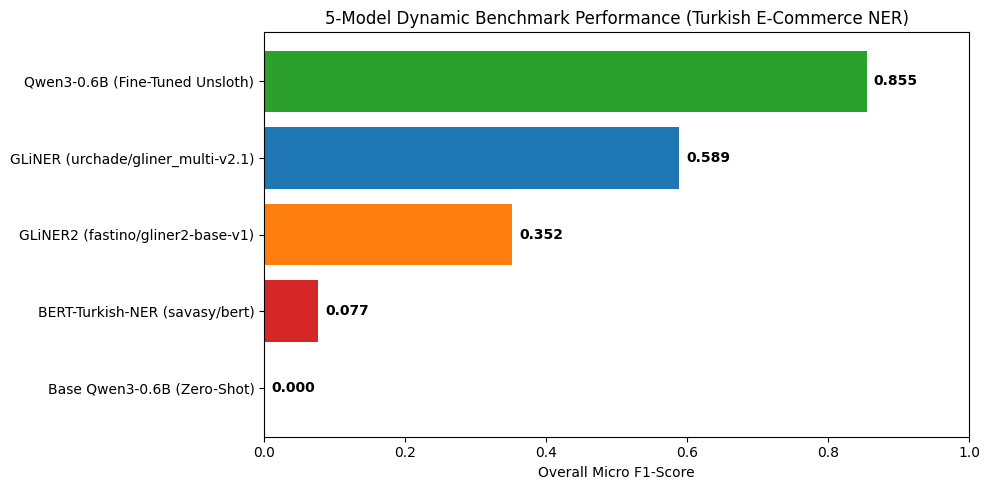

✅ Canlı metrik grafiği 'benchmark_f1_comparison.png' olarak kaydedildi.


In [32]:
# BENCHMARK SONUÇ TABLOSU VE GRAFİK GÖRSELLEŞTİRME
df_results = pd.DataFrame(benchmark_results)
# Mükerrer hücre çalıştırmalarında en son (güncel) model metriklerini koru
df_results = df_results.drop_duplicates(subset=["Model"], keep="last")
print("\n====================================================================")
print("🏆 200 KAYITLIK CANLI & DİNAMİK BENCHMARK KARŞILAŞTIRMA RAPORU")
print("====================================================================")
print(df_results.to_markdown(index=False))

plt.figure(figsize=(10, 5))
bars = plt.barh(df_results["Model"], df_results["F1-Score"], color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd'])
plt.xlabel("Overall Micro F1-Score")
plt.title("5-Model Dynamic Benchmark Performance (Turkish E-Commerce NER)")
plt.xlim(0.0, 1.0)
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f"{bar.get_width():.3f}", va='center', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("benchmark_f1_comparison.png")
plt.show()
print("✅ Canlı metrik grafiği 'benchmark_f1_comparison.png' olarak kaydedildi.")


## 8. Hugging Face Model Kartı (README.md) Jeneratörü

In [35]:
def build_notebook_model_card_readme(repo_id: str, results_df: pd.DataFrame, base_model: str = "Qwen/Qwen3-0.6B") -> str:
    """Model kartı README.md içeriğini dinamik metriklerle oluşturur."""
    try:
        table_md = results_df.to_markdown(index=False)
    except Exception:
        table_md = str(results_df)

    template = """---
license: apache-2.0
base_model: __BASE_MODEL__
tags:
- turkish
- e-commerce
- ner
- named-entity-recognition
- unsloth
- lora
- token-classification
language:
- tr
datasets:
- gururaser/turkish-ecommerce-ner-dataset
metrics:
- f1
- precision
- recall
pipeline_tag: text-generation
library_name: unsloth
---

# 🛒⚡ Qwen3-0.6B Turkish E-Commerce NER (Fine-Tuned with Unsloth)

Bu model, **`__BASE_MODEL__`** taban modeli üzerine **[gururaser/turkish-ecommerce-ner-dataset](https://huggingface.co/datasets/gururaser/turkish-ecommerce-ner-dataset)** verisetindeki 1.500 adet doğal Türkçe e-ticaret ürünü kullanılarak **NVIDIA L4 GPU** üzerinde **Unsloth + LoRA** altyapısıyla fine-tune edilmiştir.

Model, Trendyol, Hepsiburada ve Çiçeksepeti tarzındaki karmaşık Türkçe ürün isimlerinden 8 farklı Named Entity Recognition (NER) etiketini yüksek doğrulukla ve yapılandırılmış JSON formatında çıkarmaktadır.

---

## 🏆 5-Model SOTA Benchmark Karşılaştırma Raporu (200 Test Kaydı)

__TABLE__

---

## 🏷️ Desteklenen NER Etiketleri (8 Anahtar Class)

| Etiket | Açıklama | Örnek Çıktı |
|---|---|---|
| `BRAND` | Marka Adı | *Nike, Samsung, İstikbal, Karaca* |
| `CATEGORY` | Ürün Kategorisi / Türü | *Spor Ayakkabı, Akıllı TV, Koltuk Takımı* |
| `MODEL` | Model veya Ürün Serisi | *Air Max 270, Galaxy S24, Nova* |
| `COLOR` | Renk Bilgisi | *Siyah, Uzay Grisi, Bej, Lacivert* |
| `SIZE_VARIANT` | Beden / Boyut / Kapasite | *42 Numara, XL, 150x220 cm, 128 GB* |
| `GENDER_TARGET` | Hedef Kitle | *Erkek, Kadın, Çocuk, Unisex* |
| `MATERIAL` | Malzeme / Kumaş Bileşimi | *Pamuk, Deri, Paslanmaz Çelik, Granit* |
| `SPECIFICATION` | Nitelik / Teknik Özellik | *Kareli, Kablosuz, Su Geçirmez, Mat Bitiş* |

---

## 🚀 Kullanım (Usage Examples)

### Unsloth ile Hızlı İnference (Önerilen)

```python
from unsloth import FastLanguageModel
import json

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="__REPO_ID__",
    max_seq_length=512,
    load_in_4bit=True
)
FastLanguageModel.for_inference(model)

prompt_system = "Sen e-ticaret ürün isimlerinden marka, kategori, renk, beden, cinsiyet ve malzeme gibi NER bileşenlerini çıkaran uzman bir sistemdir."
user_input = "Kategori: Ayakkabı\\nÜrün Adı: Nike Air Max 270 Siyah Erkek Spor Ayakkabı 42 Numara"
prompt = f"<|im_start|>system\\n{{prompt_system}}<|im_end|>\\n<|im_start|>user\\n{{user_input}}<|im_end|>\\n<|im_start|>assistant\\n"

inputs = tokenizer([prompt], return_tensors="pt").to("cuda")
input_len = inputs["input_ids"].shape[1]

outputs = model.generate(**inputs, max_new_tokens=256)
gen_tokens = outputs[0][input_len:]

result_json = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()
print(json.loads(result_json))

```
"""

    return template.replace("__REPO_ID__", repo_id).replace("__BASE_MODEL__", base_model).replace("__TABLE__", table_md)


## 9. Modelin ve Model Kartının Hugging Face Hub'a Yüklenmesi

In [34]:
# 9. MODELİN VE DETAYLI MODEL KARTININ HUGGING FACE HUB'A PUSH EDİLMESİ
from huggingface_hub import notebook_login, HfApi, HfFolder
import os

target_repo_id = "gururaser/qwen3-0.6b-turkish-ecommerce-ner"

# 1. Hugging Face Oturum Kontrolü ve İnteraktif Giriş Widget'ı
print("🔑 Hugging Face Hub Oturumu Kontrol Ediliyor...", flush=True)
hf_token = os.getenv("HF_TOKEN") or HfFolder.get_token()

if not hf_token:
    print("👉 Lütfen Hugging Face 'Write' yetkili token'ınızı aşağıdaki kutucuğa yapıştırıp giriş yapın:")
    notebook_login()
    hf_token = HfFolder.get_token()

if hf_token:
    print(f"\n[BİLGİ] Model ve Model Kartı Hugging Face Hub'a yükleniyor: '{target_repo_id}'...")
    
    # 2. Dinamik Model Kartı (README.md) metnini üret
    card_text = build_notebook_model_card_readme(target_repo_id, df_results, base_model="Qwen/Qwen3-0.6B")
    os.makedirs("outputs", exist_ok=True)
    with open("outputs/README.md", "w", encoding="utf-8") as f:
        f.write(card_text)
    print("✅ Özenli Model Kartı 'outputs/README.md' dosyasına yazıldı.")
    
    # 3. Model ağırlıklarını 16-bit birleşik formatta yükle
    model.push_to_hub_merged(target_repo_id, tokenizer, save_method="merged_16bit", token=hf_token)
    
    # 4. Model kartını (README.md) repo'ya yükle
    api = HfApi(token=hf_token)
    api.upload_file(
        path_or_fileobj="outputs/README.md",
        path_in_repo="README.md",
        repo_id=target_repo_id,
        repo_type="model"
    )
    print(f"\n🎉 MODEL VE ÖZENLİ MODEL KARTINIZ BAŞARIYLA YAYINLANDI: https://huggingface.co/{target_repo_id}")
else:
    print("❌ Hugging Face Girişi Yapılamadı! Model yükleme adımı atlandı.")


🔑 Hugging Face Hub Oturumu Kontrol Ediliyor...

[BİLGİ] Model ve Model Kartı Hugging Face Hub'a yükleniyor: 'gururaser/qwen3-0.6b-turkish-ecommerce-ner'...
✅ Özenli Model Kartı 'outputs/README.md' dosyasına yazıldı.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mmerce-ner/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...rce-ner/model.safetensors:   5%|4         | 56.0MB / 1.19GB            

No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:15<00:00, 15.99s/it]


Unsloth: Merge process complete. Saved to `/content/gururaser/qwen3-0.6b-turkish-ecommerce-ner`

🎉 MODEL VE ÖZENLİ MODEL KARTINIZ BAŞARIYLA YAYINLANDI: https://huggingface.co/gururaser/qwen3-0.6b-turkish-ecommerce-ner
